# Introduction

Originally written by Rosa Martinez-Corral and rewritten by Melanie Weilert, the goal of this analysis is to:

1. Design a 4-conformation, 1TF kinetics model both in and out of equilibrium to estimate the relative rates of binding and accessibility in each conformation.
2. Design a 8-conformation, 2TF kinetics model out of equilibrium to estimate relative rates of binding and accessibiltiy in each conformation.

Given reasonable parameter regimes reminiscent of known values of TF (Sox2, primarily) binding in vivo in mESCs and in vitro, examine the effects of different parameters across changing concentrations on cooperativity, accessibility and binding. 

In [1]:
import sys, os
import numpy as np
import pandas as pd
from functools import partial
import matplotlib.pyplot as plt
import plotnine
from plotnine import *
import time
from scipy.linalg import null_space
import tqdm

figure_filepath = './figures/18_simulate_kinetics'
!mkdir -p {figure_filepath}
!mkdir -p tsv/kinetics

#Set variables
simulation_n = 50000

/tmp/ipykernel_4130166/471407335.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Adjacent packages

In [2]:
# ! pip install sympy
# ! pip install latex

# Design simulation functions

## Laplacian matrix derivations

These are the laplacian matrix formations to represent how one conformation transitions to another. 

In [3]:

#model with 2 sites, 2 conformations
def L_2TFs_2c(pars,A=1,B=1): #A:A, B:B
    aA_0_0,aA_0_1,bA_A_0,bA_A_1,aB_0_0,aB_0_1,bB_B_0,bB_B_1,aB_A_0,aB_A_1,bB_AB_0,bB_AB_1,aA_B_0,aA_B_1,bA_AB_0,bA_AB_1,kopen0,kclose0,kopenA,kcloseA,kopenB,kcloseB,kopenAB,kcloseAB=pars
    L=np.array([
    [0,aA_0_0*A,aB_0_0*B,0,kopen0,0,0,0], #1->1, 1->2, 1->3, 1->4, 1->5, 1->6, 1->7, 1->8  (input node, target node)
    [bA_A_0,0,0,aB_A_0*B,0,kopenA,0,0],   #2->1
    [bB_B_0,0,0,aA_B_0*A,0,0,kopenB,0],
    [0,bB_AB_0,bA_AB_0,0,0,0,0,kopenAB],
    [kclose0,0,0,0,0,aA_0_1*A,aB_0_1*B,0],
    [0,kcloseA,0,0,bA_A_1,0,0,aB_A_1*B],
    [0,0,kcloseB,0,bB_B_1,0,0,aA_B_1*A],
    [0,0,0,kcloseAB,0,bB_AB_1,bA_AB_1,0]
    ])
    return L.transpose() #we want (target node, input node)

#model with 1 sites, 2 conformations
def L_1TF_2c(pars,A=1,B=1): #A:A, B:B
    aA_0_0,aA_0_1,bA_A_0,bA_A_1,kopen0,kclose0,kopenA,kcloseA=pars
    L=np.array([
    [0,aA_0_0*A,kopen0,0], #1->1, 1->2, 1->3, 1->4 (input node, target node)
    [bA_A_0,0,0,kopenA],   #2->1
    [kclose0,0,0,aA_0_1*A], #3->1
    [0,kcloseA,bA_A_1,0]
    ])
    return L.transpose() #we want (target node, input node)


def compute_ss_fromL(L,verbose=False):
    L_d=np.diag(np.sum(L,axis=0)) #calculate the diagonal array after summing L
    
    if verbose:
        print("L",L)
        print("L_d",L_d)
    L=L-L_d
    rhos=null_space(L) #column vector
    if verbose:
        print("rhos", rhos)
        print("rhos*L", L@rhos)
    rhos=np.transpose(rhos)[0] #1 row
    
    ss=np.abs(rhos)/np.sum(np.abs(rhos)) #can be - when very close to 0
    
    return ss

def get_Popen(parset,idx_openconc=4,Lfunc=None,A=1,B=1,verbose=False):
    L=Lfunc(parset, A=A, B=B)
    ssvec=compute_ss_fromL(L,verbose=verbose)
    ssvec_open=np.sum(ssvec[idx_openconc:])
    if verbose:
        print("steady states:", ssvec)
        print("steady state sum:", np.sum(ssvec))
        print("open:", ssvec_open)
    return ssvec_open

def get_Pbound(parset, Lfunc=None, A=1,B=1,verbose=False,idxs_bound=None):
    L=Lfunc(parset,A=A, B=B)
    ssvec=compute_ss_fromL(L,verbose=verbose)
    ssvec_bound=np.sum(ssvec[idxs_bound])
    
    if verbose:
        print("steady states:", ssvec)
        print("steady state sum:", np.sum(ssvec))
        print("bound:", ssvec_bound)
    
    return ssvec_bound



## Wrapper conformation functions

These are functions that, given a parameter set `parset` and a matrix design `Lfunc`, will return expected rates of accessibility and binding. 

In [4]:
def model_2TFs_reference_nakednomotif(parset, idx_openconc=4, Lfunc=None, returnb=False, idxs_bound=None):
    #high affinity: higher affinity difference between naked-no motif and naked-motif
    
    konA,konB,koff1nA,koff1nB,gA,gB,betanA, betanB, betamA, betamB,h0,h1, kopen0,kclose0, a1nA, a1nB, a1nAB, a1mA, a1mB, a1mAnB, a1nAmB, a1mAmB, a2nA, a2nB, a2nAB, a2mA, a2mB, a2mAnB, a2nAmB, a2mAmB=parset
    
    #same for all
    aA_0_0=konA
    aA_0_1=konA
    aA_B_0=konA
    aA_B_1=konA
    aB_0_0=konB
    aB_0_1=konB
    aB_A_0=konB
    aB_A_1=konB
    
    
    
    #no motif system
    bA_A_1=koff1nA #off-rate open conformation without motif
    bA_A_0=betanA*bA_A_1
    
    bB_B_1=koff1nB
    bB_B_0=betanB*bB_B_1
    
    bA_AB_0=h0*bA_A_0
    bA_AB_1=h1*bA_A_1
    
    bB_AB_0=h0*bB_B_0
    bB_AB_1=h1*bB_B_1
    
    kopenA=a1nA*kopen0
    kopenB=a1nB*kopen0
    kopenAB=a1nAB*kopen0
    
    kcloseA=kclose0*a2nA
    kcloseB=kclose0*a2nB
    kcloseAB=kclose0*a2nAB
    
    
    parset_n=[aA_0_0,aA_0_1,bA_A_0,bA_A_1,aB_0_0,aB_0_1,bB_B_0,bB_B_1,aB_A_0,aB_A_1,bB_AB_0,bB_AB_1,aA_B_0,aA_B_1,bA_AB_0,bA_AB_1,kopen0,kclose0,kopenA,kcloseA,kopenB,kcloseB,kopenAB,kcloseAB]
    #A only motif system
    bA_A_1=gA*koff1nA
    bA_A_0=betamA*bA_A_1
    
    bB_B_1=koff1nB
    bB_B_0=betanB*bB_B_1
    
    bA_AB_0=h0*bA_A_0
    bA_AB_1=h1*bA_A_1
    
    bB_AB_0=h0*bB_B_0
    bB_AB_1=h1*bB_B_1
    
    kopenA=a1mA*kopen0
    kopenB=a1nB*kopen0
    kopenAB=a1mAnB*kopen0
    kcloseA=kclose0*a2mA
    kcloseB=kclose0*a2nB
    kcloseAB=kclose0*a2mAnB
    
    
    parset_A=[aA_0_0,aA_0_1,bA_A_0,bA_A_1,aB_0_0,aB_0_1,bB_B_0,bB_B_1,aB_A_0,aB_A_1,bB_AB_0,bB_AB_1,aA_B_0,aA_B_1,bA_AB_0,bA_AB_1,kopen0,kclose0,kopenA,kcloseA,kopenB,kcloseB,kopenAB,kcloseAB]

    #B only motif system
    bA_A_1=koff1nA
    bA_A_0=betanA*bA_A_1
    
    bB_B_1=gB*koff1nB
    bB_B_0=betamB*bB_B_1
    
    bA_AB_0=h0*bA_A_0
    bA_AB_1=h1*bA_A_1
    
    bB_AB_0=h0*bB_B_0
    bB_AB_1=h1*bB_B_1
    
    kopenA=a1nA*kopen0
    kopenB=a1mB*kopen0
    kopenAB=a1nAmB*kopen0
    kcloseA=kclose0*a2nA
    kcloseB=kclose0*a2mB
    kcloseAB=kclose0*a2nAmB
    
    
    parset_B=[aA_0_0,aA_0_1,bA_A_0,bA_A_1,aB_0_0,aB_0_1,bB_B_0,bB_B_1,aB_A_0,aB_A_1,bB_AB_0,bB_AB_1,aA_B_0,aA_B_1,bA_AB_0,bA_AB_1,kopen0,kclose0,kopenA,kcloseA,kopenB,kcloseB,kopenAB,kcloseAB]

    
    #AB motif system
    bA_A_1=gA*koff1nA
    bA_A_0=betamA*bA_A_1
    
    bB_B_1=gB*koff1nB
    bB_B_0=betamB*bB_B_1
    
    bA_AB_0=h0*bA_A_0
    bA_AB_1=h1*bA_A_1
    
    bB_AB_0=h0*bB_B_0
    bB_AB_1=h1*bB_B_1
    
    kopenA=a1mA*kopen0
    kopenB=a1mB*kopen0
    kopenAB=a1mAmB*kopen0
    kcloseA=kclose0*a2mA
    kcloseB=kclose0*a2mB
    kcloseAB=kclose0*a2mAmB
    
    
    parset_AB=[aA_0_0,aA_0_1,bA_A_0,bA_A_1,aB_0_0,aB_0_1,bB_B_0,bB_B_1,aB_A_0,aB_A_1,bB_AB_0,bB_AB_1,aA_B_0,aA_B_1,bA_AB_0,bA_AB_1,kopen0,kclose0,kopenA,kcloseA,kopenB,kcloseB,kopenAB,kcloseAB]

  
    
    A_0=get_Popen(parset_n,Lfunc=Lfunc,idx_openconc=idx_openconc)
    A_A=get_Popen(parset_A,Lfunc=Lfunc,idx_openconc=idx_openconc)
    A_B=get_Popen(parset_B,Lfunc=Lfunc,idx_openconc=idx_openconc)
    A_AB=get_Popen(parset_AB,Lfunc=Lfunc,idx_openconc=idx_openconc)
    if returnb:
        b_0=get_Pbound(parset_n,Lfunc=Lfunc,idxs_bound=idxs_bound)
        b_A=get_Pbound(parset_A,Lfunc=Lfunc,idxs_bound=idxs_bound)
        b_B=get_Pbound(parset_B,Lfunc=Lfunc,idxs_bound=idxs_bound)
        b_AB=get_Pbound(parset_AB,Lfunc=Lfunc,idxs_bound=idxs_bound)
        idxs_boundB=[idxs_bound[0]+1,idxs_bound[1],idxs_bound[2]+1,idxs_bound[3]]
        bB_0=get_Pbound(parset_n,Lfunc=Lfunc,idxs_bound=idxs_boundB)
        bB_A=get_Pbound(parset_A,Lfunc=Lfunc,idxs_bound=idxs_boundB)
        bB_B=get_Pbound(parset_B,Lfunc=Lfunc,idxs_bound=idxs_boundB)
        bB_AB=get_Pbound(parset_AB,Lfunc=Lfunc,idxs_bound=idxs_boundB)
        return [A_0, A_A, A_B, A_AB, b_0, b_A, b_B, b_AB,bB_0, bB_A, bB_B, bB_AB]
    else:    
        return [A_0, A_A, A_B, A_AB]
    
def model_2TFs_equilibrium(parset):
    #high affinity: higher affinity difference between naked-no motif and naked-motif
    
    #konA,konB,koff1nA,koff1nB,gA,gB,betanA, betanB, betamA, betamB,h0,h1, kopen0,kclose0, a1nA, a1nB, a1nAB, a1mA, a1mB, a1mAnB, a1nAmB, a1mAmB, a1nA, a1nB, a1nAB, a1mA, a1mB, a1mAnB, a1nAmB, a1mAmB, a2nA, a2nB, a2nAB, a2mA, a2mB, a2mAnB, a2nAmB, a2mAmB=parset
    konA,konB,koff1nA,koff1nB,gA,gB,betanA, betanB, betamA, betamB,h0,h1, kopen0,kclose0, a1nA, a1nB, a1nAB, a1mA, a1mB, a1mAnB, a1nAmB, a1mAmB, a2nA, a2nB, a2nAB, a2mA, a2mB, a2mAnB, a2nAmB, a2mAmB=parset
    #assumes A=1
    #nomotif
    K0A=konA/(koff1nA*betanA)
    K1A=konA/koff1nA
    K0B=konB/(koff1nB*betanB)
    K1B=konB/(koff1nB)
    w0=1/h0
    w1=1/h1
    d=kopen0/kclose0
    
    mu1=1
    mu2=K0A
    mu3=K0B
    mu4=K0A*K0B*w0
    mu5=d
    mu6=d*K1A
    mu7=d*K1B
    mu8=d*K1A*K1B*w1
    Z=mu1+mu2+mu3+mu4+mu5+mu6+mu7+mu8
    ssvec=np.array([mu1,mu2,mu3,mu4,mu5,mu6,mu7,mu8])/Z
    A_0=np.sum(ssvec[4:])
    b_0=np.sum(ssvec[[1,3,5,7]]) #binding of A
    bB_0=np.sum(ssvec[[2,3,6,7]]) #binding of B
    
    #Amotif
    K0A=konA/(koff1nA*betamA*gA)
    K1A=konA/(koff1nA*gA)
    K0B=konB/(koff1nB*betanB)
    K1B=konB/(koff1nB)
    w0=1/h0
    w1=1/h1
    d=kopen0/kclose0
    
    mu1=1
    mu2=K0A
    mu3=K0B
    mu4=K0A*K0B*w0
    mu5=d
    mu6=d*K1A
    mu7=d*K1B
    mu8=d*K1A*K1B*w1
    Z=mu1+mu2+mu3+mu4+mu5+mu6+mu7+mu8
    ssvec=np.array([mu1,mu2,mu3,mu4,mu5,mu6,mu7,mu8])/Z
    A_A=np.sum(ssvec[4:])
    b_A=np.sum(ssvec[[1,3,5,7]]) #binding of A
    bB_A=np.sum(ssvec[[2,3,6,7]]) #binding of B
    
    
    #Bmotif
    K0A=konA/(koff1nA*betanA)
    K1A=konA/(koff1nA)
    K0B=konB/(koff1nB*betamB*gB)
    K1B=konB/(koff1nB*gB)
    w0=1/h0
    w1=1/h1
    d=kopen0/kclose0
    
    mu1=1
    mu2=K0A
    mu3=K0B
    mu4=K0A*K0B*w0
    mu5=d
    mu6=d*K1A
    mu7=d*K1B
    mu8=d*K1A*K1B*w1
    Z=mu1+mu2+mu3+mu4+mu5+mu6+mu7+mu8
    ssvec=np.array([mu1,mu2,mu3,mu4,mu5,mu6,mu7,mu8])/Z
    A_B=np.sum(ssvec[4:])
    b_B=np.sum(ssvec[[1,3,5,7]]) #binding of A
    bB_B=np.sum(ssvec[[2,3,6,7]]) #binding of B
    
    #ABmotif
    K0A=konA/(koff1nA*betamA*gA)
    K1A=konA/(koff1nA*gA)
    K0B=konB/(koff1nB*betamB*gB)
    K1B=konB/(koff1nB*gB)
    w0=1/h0
    w1=1/h1
    d=kopen0/kclose0
    
    mu1=1
    mu2=K0A
    mu3=K0B
    mu4=K0A*K0B*w0
    mu5=d
    mu6=d*K1A
    mu7=d*K1B
    mu8=d*K1A*K1B*w1
    Z=mu1+mu2+mu3+mu4+mu5+mu6+mu7+mu8
    ssvec=np.array([mu1,mu2,mu3,mu4,mu5,mu6,mu7,mu8])/Z
    A_AB=np.sum(ssvec[4:])
    b_AB=np.sum(ssvec[[1,3,5,7]]) #binding of A
    bB_AB=np.sum(ssvec[[2,3,6,7]]) #binding of B
    
    
    return [A_0, A_A, A_B, A_AB, b_0, b_A, b_B, b_AB, bB_0, bB_A, bB_B, bB_AB]
    
def plot_parset_2TFs(parset,idx_openconc=4,Lfunc=None,namesave=None, modelfunc=model_2TFs_reference_nakednomotif, exprel=False, a=1, b=1):
    
    A_0, A_A, A_B, A_AB=modelfunc(parset, idx_openconc=idx_openconc, Lfunc=Lfunc)
    if exprel:
        newAvals=[]
        Popenvals=[A_0, A_A, A_B, A_AB]
        for i in range(len(Popenvals)):
            newAvals.append(from_Popen_to_atac(Popenvals[i],a=a,b=b))
        A_0, A_A, A_B, A_AB = newAvals
        
    print(A_0, A_A, A_B, A_AB)
    fA=A_A/A_0
    fB=A_B/A_0
    fAB=A_AB/A_0
    fig,axes=plt.subplots(1,3,figsize=(12,4))
    ax=axes[0]
    ax.bar(range(4),[A_0, A_A, A_B, A_AB],width=0.5,color="gray")
    if not exprel:
        ax.set_ylabel("P(open) (accessibility)")
    else:
        ax.set_ylabel("ATAC")
    ax2=ax.twinx()
    ax2.bar(np.arange(4)+0.5,[1,A_A/A_0, A_B/A_0, A_AB/A_0],color="k",width=0.5)
    ax2.set_ylabel("$f_X$")
    ax.set_xticks(range(4))
    ax.set_xticklabels(["$A_\emptyset$", "$A_A$", "$A_B$", "$A_{A,B}$"])
    ax2.axhline(y=1,linestyle="--",color="gray")
    
    ax=axes[1]
    ax.scatter(fA*fB, fAB)
    ax.set_xlabel(r"$f_A \times f_B$")
    ax.set_ylabel("$f_{A,B}$")
    ax.axline((0,0), slope=1,color="gray")
    
    ax=axes[2]
    ax.scatter(A_A-A_0+A_B-A_0,A_AB-A_0)
    ax.set_xlabel("A+B-2null")
    ax.set_ylabel("AB-null")
    coopval=np.log((A_AB-A_0)/(A_A-A_0+A_B-A_0))
    ax.set_title("coop=%g"%coopval)
        
    ax.axline((0,0), slope=1,color="gray")
    plt.tight_layout()
    if namesave:
        plt.savefig(namesave,bbox_inches="tight")
    plt.show()
    
def model_1TF_reference_nakednomotif(parset,idx_openconc=2,Lfunc=None, returnb=False, verbose=False,idxs_bound=None):
    
    
    kon,koff1nA,gA,betanA,betamA, kopen0,kclose0, a1nA,a2nA, a1mA, a2mA=parset
    
    
    #same for all
    aA_0_0=kon
    aA_0_1=kon
    
    #no motif system
    bA_A_1=koff1nA
    bA_A_0=betanA*bA_A_1
    
    kopenA=a1nA*kopen0
    kcloseA=a2nA*kclose0
    
    
    parset_n=[aA_0_0,aA_0_1,bA_A_0,bA_A_1,kopen0,kclose0,kopenA,kcloseA]
    if verbose:
        print("n", aA_0_0/bA_A_0, aA_0_1/bA_A_1, kopen0/kclose0, kopenA/kcloseA, (aA_0_0/bA_A_0)*(kopenA/kcloseA),(aA_0_1/bA_A_1)*(kopen0/kclose0))
    
    #A only motif system
    bA_A_1=gA*koff1nA
    bA_A_0=betamA*bA_A_1
    
    
    kopenA=a1mA*kopen0
    kcloseA=a2mA*kclose0
    
    
    parset_A=[aA_0_0,aA_0_1,bA_A_0,bA_A_1,kopen0,kclose0,kopenA,kcloseA]
    if verbose:
        print("m", aA_0_0/bA_A_0, aA_0_1/bA_A_1, kopen0/kclose0, kopenA/kcloseA)

    
    
    A_0=get_Popen(parset_n,Lfunc=Lfunc,idx_openconc=idx_openconc, verbose=verbose)
    if returnb:
        if verbose:
            print("without motif", "A:",A_0)
        b_0=get_Pbound(parset_n,Lfunc=Lfunc, verbose=verbose,idxs_bound=idxs_bound)
        
    A_A=get_Popen(parset_A,Lfunc=Lfunc,idx_openconc=idx_openconc,verbose=verbose)
    if returnb:
        if verbose:
            print("with motif", "A:",A_A)
        b_A=get_Pbound(parset_A,Lfunc=Lfunc, verbose=verbose, idxs_bound=idxs_bound)
        return [A_0, A_A, b_0, b_A]
    else:
    
        return [A_0, A_A]
    
def model_1TF_equilibrium(parset, A=1):
    kon,koff1nA,gA,betanA,betamA, kopen0,kclose0, a1nA,a2nA, a1mA, a2mA = parset
    d=kopen0/kclose0
    mu0=1
    #no motif
    K1=kon*A/koff1nA
    K0=(kon*A)/(betanA*koff1nA)
    Znomotif=mu0+K0+d+d*K1
    A_0=(d+d*K1)/Znomotif
    b_0=(K0+d*K1)/Znomotif
    #motif
    K1=(kon*A/(gA*koff1nA))
    K0=(kon*A)/(betamA*gA*koff1nA)
    Zmotif=mu0+K0+d+d*K1
    A_A=(d+d*K1)/Zmotif
    b_A=(K0+d*K1)/Zmotif
    return [A_0, A_A, b_0, b_A]
    

def plot_parset_1TF(parset,idx_openconc=2,Lfunc=None,namesave=None):
    
    A_0, A_A=model_1TF_reference_nakednomotif(parset,idx_openconc=idx_openconc,Lfunc=Lfunc)
    
    fA=A_A/A_0
    
    fig,ax=plt.subplots(1,1,figsize=(10,4))
    ax.bar(range(2),[A_0, A_A],width=0.5,color="gray")
    ax.set_ylabel("P(open) (accessibility)")
    ax2=ax.twinx()
    ax2.bar(np.arange(2)+0.5,[1,A_A/A_0],color="k",width=0.5)
    ax2.set_ylabel("$f_X$")
    ax.set_xticks(range(2))
    ax.set_xticklabels(["$A_\emptyset$", "$A_A$"])
    ax2.axhline(y=1,linestyle="--",color="gray")
    
    plt.tight_layout()
    if namesave:
        plt.savefig(namesave,bbox_inches="tight")
    plt.show()
    

# Proof of superadditivity: multiplicative combined effects

Now assume that the fold changes by which each TF affects a rate multiply. This is what would come out if the two TFs are assumed to lower the activation energy of a reaction additively:

Following Arrhenius law:

$k=C\times exp(-E/(RT))$

$k_A = C\times exp(-(E-x_A)/(RT)) = k \times f_A$

$k_B = C\times exp(-(E-x_B)/(RT)) = k \times f_B$

$k_{A,B} = C\times exp(-(E-x_A-x_B)/(RT)) = k \times f_A \times f_B$

 

# Simulate 1TF, 4-state pioneering


## Helper functions

In [5]:
def generate_L_1TF_2c(gA_list, #affinities of each TF
                       a1A_list, #opening effects of each TF
                       a2Af_list, #closing effects of each TF
                       betanA_list = [2,4],  #RMC - factor increase in off-rate due to nucleosome, non-specific DNAMelanie-likelihood to bind to the nucleosome
                       betamA_list = [5,10],  # - factor increase in off-rate due to nucleosome, DNA with motif #Mel-likelihood to bind to the nucleosome
                       d_list = [.01, .1],
                       idxs_bound = [1,3], #indexes that are the states we need to collect probabilities from (BOUND)
                       idx_openconc = 2, #index we start at that are the states we need to collect probabilities from (ACC)
                       h1=1, h0=1, #binding interactions BETWEEN two TFs
                       trials = 10000): #extra parameters
    """
    A given TF increases the opening rate by an amount i_x, and when both are bound, the amounts multiplies, 8-state model
    Consider only parameter sets where both A and B individually increase accessibility
    Assume that the effect of the TF does not change when it is bound to a motif with respect to when it is bound non-specifically 
    """      
    gAvals=[]; a1Avals=[]; a2Avals=[]; 
    parsets=[]; A0vals=[]; AAvals=[]; b0vals=[]; bAvals=[]

    negativepsets=0
    for i in range(trials):
        np.random.seed(i)

        kopen0=0.001 #10**np.random.uniform(-4,-2) #assume opening happens in the minutes to hours range
        d=np.random.uniform(d_list[0],d_list[1]) #if dmax is too large, then less cooperativity because it is already open
        kclose0=kopen0/d #np.random.uniform(0.001,0.01)
    
        kon=0.1
        KA=1 #np.random.uniform(1,5)
        koff1nA=kon/KA
        
        gA=np.random.uniform(gA_list[0],gA_list[1]) 

        a1A=np.random.uniform(a1A_list[0],a1A_list[1]) 
        a1Afactorincrease=1 #np.random.uniform(1,3) #small values here generate more cooperativity. If 1, assume same effect with and without motif, the only thing that matters is whether it is bound or not. 
        a1nA=a1A
        a1mA=a1nA*a1Afactorincrease

        betanA=np.random.uniform(betanA_list[0],betanA_list[1]) #np.random.normal(5,0.1)
        betamA=np.random.uniform(betamA_list[0],betamA_list[1])

        #assume some effect on the closing
        a2mAf=np.random.uniform(a2Af_list[0], a2Af_list[1]) #a2nAf*np.random.uniform(1,2) #min(np.random.normal(0.8,0.15),1) 
        a2nAf = a2mAf
        
        a2nA=1/a2nAf; a2mA=1/a2mAf;
        assert a2nA==a2mA

        parset = [kon, koff1nA, gA, betanA, betamA, kopen0,kclose0, a1nA,a2nA, a1mA, a2mA]
        parsetar=np.array(parset)

        if not np.all(parsetar>0):
            negativepsets+=1
        else:
            [A_0, A_A, b_0, b_A] =model_1TF_reference_nakednomotif(parset, idx_openconc=idx_openconc, Lfunc=L_1TF_2c, idxs_bound = idxs_bound, returnb = True)
            if A_A>=A_0:
                gAvals.append(gA); 
                parsets.append(parset);
                A0vals.append(A_0);AAvals.append(A_A);
                b0vals.append(b_0);bAvals.append(b_A);
                a1Avals.append(a1nA);a2Avals.append(a2nAf);
 
    print("negativepsets", negativepsets)
    
    #Append to pd.df
    outcome_df = pd.DataFrame([gAvals, a1Avals, a2Avals, A0vals, AAvals, b0vals, bAvals]).transpose()
    outcome_df.columns = ['gAvals', 'a1Avals', 'a2Avals', 'acc_null', 'acc_A', 'bind_null', 'bind_A']
    return outcome_df

In [6]:
def generate_L_1TF_2c_c1overbeta(gA_list, #affinities of each TF
                       a1A_list, #opening effects of each TF
                       a2Af_list, #closing effects of each TF
                       betanA_list = [2,4],  #RMC - factor increase in off-rate due to nucleosome, non-specific DNAMelanie-likelihood to bind to the nucleosome
                       betamA_list = [5,10],  # - factor increase in off-rate due to nucleosome, DNA with motif #Mel-likelihood to bind to the nucleosome
                       idxs_bound = [1,3], #indexes that are the states we need to collect probabilities from (BOUND)
                       idx_openconc = 2, #index we start at that are the states we need to collect probabilities from (ACC)
                       d_list = [.01, .1],
                       h1=1, h0=1, #binding interactions BETWEEN two TFs
                       trials = 10000): #extra parameters
    """
    A given TF increases the opening rate by an amount i_x, and when both are bound, the amounts multiplies, 8-state model
    Consider only parameter sets where both A and B individually increase accessibility
    Assume that the effect of the TF does not change when it is bound to a motif with respect to when it is bound non-specifically 
    """      
    gAvals=[]; a1Avals=[]; a2Avals=[]; 
    parsets=[]; A0vals=[]; AAvals=[]; b0vals=[]; bAvals=[]

    negativepsets=0
    for i in range(trials):
        np.random.seed(i)
        
        kopen0=0.001 #10**np.random.uniform(-4,-2) #assume opening happens in the minutes to hours range
        d=np.random.uniform(d_list[0],d_list[1]) #if dmax is too large, then less cooperativity because it is already open
        kclose0=kopen0/d #np.random.uniform(0.001,0.01)
    
        kon=0.1
        KA=1 #np.random.uniform(1,5)
        koff1nA=kon/KA
        
        gA=np.random.uniform(gA_list[0],gA_list[1]) 

        a1A=np.random.uniform(a1A_list[0],a1A_list[1]) 
        a1Afactorincrease=1 #np.random.uniform(1,3) #small values here generate more cooperativity. If 1, assume same effect with and without motif, the only thing that matters is whether it is bound or not. 
        a1nA=a1A
        a1mA=a1nA*a1Afactorincrease

        betanA=np.random.uniform(betanA_list[0],betanA_list[1]) #np.random.normal(5,0.1)
        betamA=np.random.uniform(betamA_list[0],betamA_list[1])

        #assume some effect on the closing
        #a2mAf=np.random.uniform(a2Af_list[0], a2Af_list[1]) #a2nAf*np.random.uniform(1,2) #min(np.random.normal(0.8,0.15),1) 
        #a2nAf = a2mAf
        
        #a2nA=1/a2nAf; a2mA=1/a2mAf;
        #assert a2nA==a2mA
        a2nA=1/betanA
        a2mA=1/betamA
        a2nAf=1/a2nA
        a2mAf=1/a2mA

        parset = [kon, koff1nA, gA, betanA, betamA, kopen0,kclose0, a1nA,a2nA, a1mA, a2mA]
        parsetar=np.array(parset)

        if not np.all(parsetar>0):
            negativepsets+=1
        else:
            [A_0, A_A, b_0, b_A] =model_1TF_reference_nakednomotif(parset, idx_openconc=idx_openconc, Lfunc=L_1TF_2c, idxs_bound = idxs_bound, returnb = True)
            if A_A>=A_0:
                gAvals.append(gA); 
                parsets.append(parset);
                A0vals.append(A_0);AAvals.append(A_A);
                b0vals.append(b_0);bAvals.append(b_A);
                a1Avals.append(a1nA);a2Avals.append(a2nAf);
 
    print("negativepsets", negativepsets)
    
    #Append to pd.df
    outcome_df = pd.DataFrame([gAvals, a1Avals, a2Avals, A0vals, AAvals, b0vals, bAvals]).transpose()
    outcome_df.columns = ['gAvals', 'a1Avals', 'a2Avals', 'acc_null', 'acc_A', 'bind_null', 'bind_A']
    return outcome_df

## Non-pioneering showcase

Showcase that when c and o are closed, you don't get pioneering. Basic control of model parameters.

In [7]:
trial_n = 10000
outcome_df = generate_L_1TF_2c(gA_list=[0.1, 0.9], 
                               a1A_list=[1,1],
                               a2Af_list=[1,1], 
                               # betanA_list = [1,1],
                               # betamA_list = [1,1],
                               trials = trial_n)
outcome_df['acc_Pmarg'] = outcome_df['acc_A'] - outcome_df['acc_null']
outcome_df['bind_Pmarg'] = outcome_df['bind_A'] - outcome_df['bind_null']
outcome_df['acc_logmarg'] = np.log(outcome_df['acc_A']) - np.log(outcome_df['acc_null'])
outcome_df['bind_logmarg'] = np.log(outcome_df['bind_A']) - np.log(outcome_df['bind_null'])
outcome_df['affinity'] = 1/outcome_df['gAvals']

outcome_df.to_csv('tsv/kinetics/kinetics_4state_nonpioneering.tsv.gz', sep = '\t', index = False)
outcome_df.head()

negativepsets 0


,gAvals,a1Avals,a2Avals,acc_null,acc_A,bind_null,bind_A,acc_Pmarg,bind_Pmarg,acc_logmarg,bind_logmarg,affinity
0,0.120741,1.0,1.0,0.046929,0.046929,0.269191,0.553965,8.326673e-17,0.284774,1.776357e-15,0.721681,8.282192
1,0.666518,1.0,1.0,0.056223,0.056223,0.262236,0.161035,2.081668e-17,-0.101202,4.440892e-16,-0.487627,1.500334
2,0.537786,1.0,1.0,0.088450,0.088450,0.249359,0.219428,2.636780e-16,-0.029932,3.108624e-15,-0.127872,1.859476
3,0.365584,1.0,1.0,0.082870,0.082870,0.338609,0.362533,0.000000e+00,0.023923,0.000000e+00,0.068268,2.735351
4,0.723935,1.0,1.0,0.016588,0.016588,0.228865,0.128613,1.769418e-16,-0.100252,1.065814e-14,-0.576326,1.381339


In [8]:
nonpioneer_plot = (ggplot(data = outcome_df, mapping = aes(x = 'bind_logmarg', y = 'acc_logmarg', color = 'affinity'))+
    geom_abline(intercept = 0, slope = 1, color = 'red')+
    geom_point()+
    scale_x_continuous(limits = (-.5,2))+
    scale_y_continuous(limits = (-.5,2))+
    ggtitle('Nonpioneering with no prevention') + 
    theme_classic())
nonpioneer_plot.save(f'{figure_filepath}/nonpioneering_bind_vs_acc.png', dpi = 300)
nonpioneer_plot.save(f'{figure_filepath}/nonpioneering_bind_vs_acc.pdf')

/home/mw2098/anaconda3/envs/bpreveal_404/lib/python3.11/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/mw2098/anaconda3/envs/bpreveal_404/lib/python3.11/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: ./figures/18_simulate_kinetics/nonpioneering_bind_vs_acc.png
/home/mw2098/anaconda3/envs/bpreveal_404/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 905 rows containing missing values.
/home/mw2098/anaconda3/envs/bpreveal_404/lib/python3.11/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/mw2098/anaconda3/envs/bpreveal_404/lib/python3.11/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: ./figures/18_simulate_kinetics/nonpioneering_bind_vs_acc.pdf
/home/mw2098/anaconda3/envs/bpreveal_404/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 905 rows containing missing values.


## Simple pioneering (Sox2)

In [9]:
trial_n = 10000
outcome_df = generate_L_1TF_2c(gA_list=[0.1, 0.9], 
                               a1A_list=[5,5],
                               a2Af_list=[1,1], 
                               # betanA_list = [1,1],
                               # betamA_list = [1,1],
                               trials = trial_n)
outcome_df['acc_Pmarg'] = outcome_df['acc_A'] - outcome_df['acc_null']
outcome_df['bind_Pmarg'] = outcome_df['bind_A'] - outcome_df['bind_null']
outcome_df['acc_logmarg'] = np.log(outcome_df['acc_A']) - np.log(outcome_df['acc_null'])
outcome_df['bind_logmarg'] = np.log(outcome_df['bind_A']) - np.log(outcome_df['bind_null'])
outcome_df['affinity'] = 1/outcome_df['gAvals']

outcome_df.to_csv('tsv/kinetics/kinetics_4state_pioneering.tsv.gz', sep = '\t', index = False)
outcome_df.head()

negativepsets 0


,gAvals,a1Avals,a2Avals,acc_null,acc_A,bind_null,bind_A,acc_Pmarg,bind_Pmarg,acc_logmarg,bind_logmarg,affinity
0,0.120741,5.0,1.0,0.090908,0.134486,0.280867,0.585644,0.043578,0.304777,0.391616,0.734831,8.282192
1,0.365584,5.0,1.0,0.171537,0.173487,0.355100,0.400151,0.001950,0.045050,0.011301,0.119441,2.735351
2,0.116602,5.0,1.0,0.130390,0.199474,0.258921,0.605542,0.069084,0.346620,0.425155,0.849598,8.576215
3,0.115580,5.0,1.0,0.047404,0.077395,0.238156,0.575813,0.029991,0.337657,0.490217,0.882856,8.652001
4,0.290033,5.0,1.0,0.126493,0.140220,0.240638,0.330261,0.013726,0.089623,0.103022,0.316589,3.447884


In [10]:
pioneer_plot =(ggplot(data = outcome_df, mapping = aes(x = 'bind_logmarg', y = 'acc_logmarg', color = 'affinity'))+
    geom_abline(intercept = 0, slope = 1, color = 'red')+
    geom_point()+
    scale_x_continuous(limits = (-.5,2))+
    scale_y_continuous(limits = (-.5,2))+
    ggtitle('Simple pioneering') + 
    theme_classic())
pioneer_plot.save(f'{figure_filepath}/simplepioneering_bind_vs_acc.png', dpi = 300)
pioneer_plot.save(f'{figure_filepath}/simplepioneering_bind_vs_acc.pdf')

/home/mw2098/anaconda3/envs/bpreveal_404/lib/python3.11/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/mw2098/anaconda3/envs/bpreveal_404/lib/python3.11/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: ./figures/18_simulate_kinetics/simplepioneering_bind_vs_acc.png
/home/mw2098/anaconda3/envs/bpreveal_404/lib/python3.11/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/mw2098/anaconda3/envs/bpreveal_404/lib/python3.11/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: ./figures/18_simulate_kinetics/simplepioneering_bind_vs_acc.pdf


# Simulate 2TF, 8-state pioneering over static concentration

Here, we will simulate the 8-state conformation of 2TFs being in open/closed confifurations with/without motifs.

## Helper functions

In [11]:
def generate_L_2TFs_2c(gA_list, gB_list, #affinities of each TF
                       a1A_list, a1B_list, #opening effects of each TF
                       a2Af_list, a2Bf_list, #closing effects of each TF
                       betanA_list = [2,4],  betanB_list = [2,4], #increase in off-rate due to nucleosome, non-specific DNA
                       betamA_list = [5, 10],  betamB_list = [5, 10], #increase in off-rate due to nucleosome, DNA with motif
                       kopen0=0.001, konA = .1, konB = .1, KA = 1, 
                       d_list=[.001,0.05],
                       h1=1, h0=1, #binding interactions BETWEEN two TFs
                       trials = 10000): #extra parameters
    """
    A given TF increases the opening rate by an amount i_x, and when both are bound, the amounts multiplies, 8-state model
    Consider only parameter sets where both A and B individually increase accessibility
    Assume that the effect of the TF does not change when it is bound to a motif with respect to when it is bound non-specifically 
    """      
    yvals=[]; xvals=[]; gAvals=[]; gBvals=[]; a1Avals=[]; a1Bvals=[]; a2Avals=[]; a2Bvals=[]; 
    parsets=[]; A0vals=[]; AAvals=[]; ABvals=[]; AABvals=[]
    # bA_0vals = []; bA_Avals = []; bA_Bvals = []; bA_ABvals.append(b_AB);
    # bB_0vals.append(bB_0);bB_Avals.append(bB_A);bB_Bvals.append(bB_B);bB_ABvals.append(bB_AB);    

    negativepsets=0
    for i in range(trials):
        np.random.seed(i)
        # kopen0=0.001 #10**np.random.uniform(-4,-2) #assume opening happens in the minutes to hours range
        d=np.random.uniform(d_list[0],d_list[1]) #if dmax is too large, then less cooperativity because it is already open
        kclose0=kopen0/d #np.random.uniform(0.001,0.01)
    
        # konA=konB=0.1
        # KA=1 #np.random.uniform(1,5)
        koff1nA=konA/KA
        koff1nB=konB/KA
        
        gA=np.random.uniform(gA_list[0],gA_list[1]) 
        gB=np.random.uniform(gB_list[0],gB_list[1])
        
        a1A=np.random.uniform(a1A_list[0],a1A_list[1]) 
        a1Afactorincrease=1 #np.random.uniform(1,3) #small values here generate more cooperativity, 
        a1nA=a1A
        a1mA=a1nA*a1Afactorincrease
    
        a1B=np.random.uniform(a1B_list[0],a1B_list[1]) 
        a1Bfactorincrease=1 #np.random.uniform(1,2)
        a1nB=a1B
        a1mB=a1nB*a1Bfactorincrease
    
        betanA=np.random.uniform(betanA_list[0],betanA_list[1]) #np.random.normal(5,0.1)
        betamA=np.random.uniform(betamA_list[0],betamA_list[1])
    
        betanB=np.random.uniform(betanB_list[0],betanB_list[1]) #np.random.normal(5,0.1)
        betamB=np.random.uniform(betamB_list[0],betamB_list[1])

    
        #assume some effect on the closing
        a2mAf=np.random.uniform(a2Af_list[0], a2Af_list[1]) #a2nAf*np.random.uniform(1,2) #min(np.random.normal(0.8,0.15),1) 
        a2nAf = a2mAf
        
        a2mBf=np.random.uniform(a2Bf_list[0], a2Bf_list[1]) #a2nBf*np.random.uniform(1,2) #np.random.uniform(1,2) #min(np.random.normal(0.8,0.15),1) 
        a2nBf = a2mBf
        
        a2nA=1/a2nAf; a2mA=1/a2mAf; a2nB=1/a2nBf; a2mB=1/a2mBf
        assert a2nA==a2mA
        assert a2nB==a2mB
            
        a1nAB=a1nA*a1nB; a1mAmB=a1mA*a1mB; a1mAnB=a1mA*a1nB; a1nAmB=a1nA*a1mB
        a2nAB=1/(a2nAf*a2nBf); a2mAnB=1/(a2mAf*a2nBf); a2nAmB=1/(a2nAf*a2mBf); a2mAmB=1/(a2mAf*a2mBf)
    
        
        parset=[konA,konB,koff1nA,koff1nB,gA,gB,betanA, betanB, betamA, betamB,h0,h1, kopen0,kclose0, a1nA, a1nB, a1nAB, a1mA, a1mB, a1mAnB, a1nAmB, a1mAmB, a2nA, a2nB, a2nAB, a2mA, a2mB, a2mAnB, a2nAmB, a2mAmB]
        parsetar=np.array(parset)
        if not np.all(parsetar>0):
            negativepsets+=1
        else:
            A_0, A_A, A_B, A_AB =model_2TFs_reference_nakednomotif(parset, idx_openconc=4, Lfunc=L_2TFs_2c)
            # A_0, A_A, A_B, A_AB, b_0, b_A, b_B, b_AB,bB_0, bB_A, bB_B, bB_AB =model_2TFs_reference_nakednomotif(parset, idx_openconc=4, Lfunc=L_2TFs_2c)
            if A_A>A_0 and A_B>A_0:
                yvals.append(A_AB-A_0);xvals.append(A_A-A_0+A_B-A_0)
                gAvals.append(gA);gBvals.append(gB)
                parsets.append(",".join(list(map(str,parset))));
                A0vals.append(A_0);AAvals.append(A_A);ABvals.append(A_B);AABvals.append(A_AB);
                a1Avals.append(a1nA);a1Bvals.append(a1nB);a2Avals.append(a2nAf);a2Bvals.append(a2nBf);
                # bA_0vals.append(b_0);bA_Avals.append(b_A);bA_Bvals.append(b_B);bA_ABvals.append(b_AB);
                # bB_0vals.append(bB_0);bB_Avals.append(bB_A);bB_Bvals.append(bB_B);bB_ABvals.append(bB_AB);
                
    #print("negativepsets",negativepsets)
    yvalsar=np.array(yvals)
    xvalsar=np.array(xvals)
    
    coopvals=np.log(yvalsar/xvalsar)
    coopvals=np.log(yvalsar/xvalsar)
    
    #Append to pd.df
    outcome_df = pd.DataFrame([yvalsar, xvalsar, gAvals, gBvals, a1Avals, a1Bvals, a2Avals, a2Bvals, coopvals,
                              A0vals, AAvals, ABvals, AABvals, parsets]).transpose()
    outcome_df.columns = ['acc_joint', 'acc_marg', 'gAvals', 'gBvals', 'a1Avals', 'a1Bvals', 'a2Avals', 'a2Bvals', 'acc_coopvals',
                         'acc_null','acc_A','acc_B','acc_AB', 'parset']
    return outcome_df

In [12]:
def generate_input_output_2TFs_2c_Aonlychange_ns(gA_list, gB_list, #affinities of each TF
                       a1A_list, a1B_list, #opening effects of each TF
                       a2Af_list, a2Bf_list, #closing effects of each TF
                       betanA_list = [2,4],  betanB_list = [2,4], #increase in off-rate due to nucleosome, non-specific DNA
                       betamA_list = [5, 10],  betamB_list = [5, 10], #increase in off-rate due to nucleosome, DNA with motif
                       kopen0=0.001, konrange=None, koff=1, 
                       d_list=[.001,0.05],
                       h1=1, h0=1, #binding interactions BETWEEN two TFs
                       trials = 10000,
                       sameclosingeffect=True): #extra parameters
    """
    A given TF increases the opening rate by an amount i_x, and when both are bound, the amounts multiplies, 8-state model
    Consider only parameter sets where both A and B individually increase accessibility
    Assume that the effect of the TF does not change when it is bound to a motif with respect to when it is bound non-specifically (sameclosingeffect=True), or only a1 does not change.
    """      
    #yvals=[]; xvals=[]; gAvals=[]; gBvals=[]; a1Avals=[]; a1Bvals=[]; a2Avals=[]; a2Bvals=[]; 
    parsets=[]; A0vals=[]; AAvals=[]; ABvals=[]; AABvals=[]
    AAalonevals=[];ABalonevals=[];
    bAalonevals=[];bBalonevals=[];bA_ABvals=[];bB_ABvals=[];
    cooperativities=[];
    # bA_0vals = []; bA_Avals = []; bA_Bvals = []; bA_ABvals.append(b_AB);
    # bB_0vals.append(bB_0);bB_Avals.append(bB_A);bB_Bvals.append(bB_B);bB_ABvals.append(bB_AB);    
    
    negativepsets=0
    
    for i in range(trials):
        np.random.seed(i)
        # kopen0=0.001 #10**np.random.uniform(-4,-2) #assume opening happens in the minutes to hours range
        d=np.random.uniform(d_list[0],d_list[1]) #if dmax is too large, then less cooperativity because it is already open
        kclose0=kopen0/d #np.random.uniform(0.001,0.01)
    
        konA=konB=0.1 #redundant, see below it gets redefined
        # KA=1 #np.random.uniform(1,5)
        koff1nA=koff
        koff1nB=koff
        
        gA=np.random.uniform(gA_list[0],gA_list[1]) 
        gB=np.random.uniform(gB_list[0],gB_list[1])
        
        a1A=np.random.uniform(a1A_list[0],a1A_list[1]) 
        a1Afactorincrease=1 #np.random.uniform(1,3) #small values here generate more cooperativity, 
        a1nA=a1A
        a1mA=a1nA*a1Afactorincrease
    
        a1B=np.random.uniform(a1B_list[0],a1B_list[1]) 
        a1Bfactorincrease=1 #np.random.uniform(1,2)
        a1nB=a1B
        a1mB=a1nB*a1Bfactorincrease
    
        betanA=np.random.uniform(betanA_list[0],betanA_list[1]) #np.random.normal(5,0.1)
        betamA=np.random.uniform(betamA_list[0],betamA_list[1])
    
        betanB=np.random.uniform(betanB_list[0],betanB_list[1]) #np.random.normal(5,0.1)
        betamB=np.random.uniform(betamB_list[0],betamB_list[1])

    
        #assume some effect on the closing
        a2mAf=np.random.uniform(a2Af_list[0], a2Af_list[1]) #a2nAf*np.random.uniform(1,2) #min(np.random.normal(0.8,0.15),1) 
        if sameclosingeffect:
            a2nAf = a2mAf
        else:
            a2nAf=1
        
        a2mBf=np.random.uniform(a2Bf_list[0], a2Bf_list[1]) #a2nBf*np.random.uniform(1,2) #np.random.uniform(1,2) #min(np.random.normal(0.8,0.15),1) 
        if sameclosingeffect:
            a2nBf = a2mBf
        else:
            a2nBf=1
        
        a2nA=1/a2nAf; a2mA=1/a2mAf; a2nB=1/a2nBf; a2mB=1/a2mBf
        #assert a2nA==a2mA
        #assert a2nB==a2mB
            
        a1nAB=a1nA*a1nB; a1mAmB=a1mA*a1mB; a1mAnB=a1mA*a1nB; a1nAmB=a1nA*a1mB
        a2nAB=1/(a2nAf*a2nBf); a2mAnB=1/(a2mAf*a2nBf); a2nAmB=1/(a2nAf*a2mBf); a2mAmB=1/(a2mAf*a2mBf)
    
        parslist=[koff1nA,koff1nB,gA,gB,betanA, betanB, betamA, betamB,h0,h1, kopen0,kclose0, a1nA, a1nB, a1nAB, a1mA, a1mB, a1mAnB, a1nAmB, a1mAmB, a2nA, a2nB, a2nAB, a2mA, a2mB, a2mAnB, a2nAmB, a2mAmB]

        A0vals_=[]; AAvals_=[]; ABvals_=[]; AABvals_=[]
        AAalonevals_=[];ABalonevals_=[];bAalonevals_=[];bBalonevals_=[];bA_ABvals_=[];bB_ABvals_=[];
        cooperativity_=[]
        parset_list = []
        
        for kon in konrange:
            
            parset=[kon,konB]+parslist
                
            parsetar=np.array(parset)
            if not np.all(parsetar>=0):
                negativepsets+=1
                print("negativepsets")

            else:
                parsetA=np.array([kon,koff1nA,gA,betanA,betamA, kopen0,kclose0, a1nA,a2nA, a1mA, a2mA])
                parsetB=np.array([konB,koff1nB,gB,betanB,betamB,kopen0,kclose0,a1nB,a2nB,a1mB,a2mB])
                
                A0_Aalone, A_Aalone, b0_Aalone, bA_Aalone=model_1TF_reference_nakednomotif(parsetA,idx_openconc=2,Lfunc=L_1TF_2c, 
                                                                                           returnb=True, idxs_bound=[1,3])
                A0_Balone, A_Balone, b0_Balone, bA_Balone=model_1TF_reference_nakednomotif(parsetB,idx_openconc=2,Lfunc=L_1TF_2c, 
                                                                                           returnb=True, idxs_bound=[1,3])
                # A_0, A_A, A_B, A_AB =model_2TFs_reference_nakednomotif(parsetar, idx_openconc=4, Lfunc=L_2TFs_2c)
                A_0, A_A, A_B, A_AB, b_0, b_A, b_B, b_AB,bB_0, bB_A, bB_B, bB_AB =model_2TFs_reference_nakednomotif(parset, idx_openconc=4, Lfunc=L_2TFs_2c, 
                                                                                                                    returnb=True, idxs_bound=[1,3,5,7])
                A0vals_.append(A_0);AAvals_.append(A_A);ABvals_.append(A_B);AABvals_.append(A_AB);
                AAalonevals_.append(A_Aalone);
                ABalonevals_.append(A_Balone)
                
                bAalonevals_.append(bA_Aalone);
                bBalonevals_.append(bA_Balone)
                bA_ABvals_.append(b_AB)
                bB_ABvals_.append(bB_AB)
                
                parset_list.append(parset)
                if A_AB-A_0<1e-10:
                    cooperativity_.append(-1000)
                else:
                    cooperativity_.append(np.log((A_AB-A_0)/(1e-10+A_A-A_0+A_B-A_0)))
        A0vals.append(",".join(list(map(str,A0vals_))))
        AAvals.append(",".join(list(map(str,AAvals_))))
        ABvals.append(",".join(list(map(str,ABvals_))))
        AABvals.append(",".join(list(map(str,AABvals_))))
        AAalonevals.append(",".join(list(map(str,AAalonevals_))))
        ABalonevals.append(",".join(list(map(str,ABalonevals_))))

        bAalonevals.append(",".join(list(map(str,bAalonevals_))))
        bBalonevals.append(",".join(list(map(str,bBalonevals_))))
        bA_ABvals.append(",".join(list(map(str,bA_ABvals_))))
        bB_ABvals.append(",".join(list(map(str,bB_ABvals_))))
 
        cooperativities.append(",".join(list(map(str,cooperativity_))))
        parsets.append(",".join(list(map(str,parset))));
                
        
    outcome_df = pd.DataFrame([cooperativities,A0vals, AAvals, ABvals, AABvals,AAalonevals,ABalonevals, bAalonevals, bBalonevals, bA_ABvals, bB_ABvals, parsets]).transpose()
    outcome_df.columns = ['acc_coopvals','acc_null','acc_A','acc_B','acc_AB', 'acc_Aonly','acc_Bonly','bind_Aonly','bind_Bonly','bindA_ABonly', 'bindB_ABonly', 'parset']
    return outcome_df
        

In [13]:
def generate_L_2TFs_2c_c1overbeta(gA_list, gB_list, #affinities of each TF
                       a1A_list, a1B_list, #opening effects of each TF
                       betanA_list = [2,4],  betanB_list = [2,4], #increase in off-rate due to nucleosome, non-specific DNA
                       betamA_list = [5, 10],  betamB_list = [5, 10], #increase in off-rate due to nucleosome, DNA with motif
                       kopen0=0.001, konA = .1, konB = .1, KA = 1, 
                       d_list=[.001,0.05],
                       h1=1, h0=1, #binding interactions BETWEEN two TFs
                       trials = 10000): #extra parameters
    """
    A given TF increases the opening rate by an amount i_x, and when both are bound, the amounts multiplies, 8-state model
    Consider only parameter sets where both A and B individually increase accessibility
    Assume that the effect of the TF does not change when it is bound to a motif with respect to when it is bound non-specifically 
    """      
    yvals=[]; xvals=[]; gAvals=[]; gBvals=[]; a1Avals=[]; a1Bvals=[]; a2Avals=[]; a2Bvals=[]; 
    parsets=[]; A0vals=[]; AAvals=[]; ABvals=[]; AABvals=[]
    # bA_0vals = []; bA_Avals = []; bA_Bvals = []; bA_ABvals.append(b_AB);
    # bB_0vals.append(bB_0);bB_Avals.append(bB_A);bB_Bvals.append(bB_B);bB_ABvals.append(bB_AB);    

    negativepsets=0
    for i in range(trials):
        np.random.seed(i)
        # kopen0=0.001 #10**np.random.uniform(-4,-2) #assume opening happens in the minutes to hours range
        d=np.random.uniform(d_list[0],d_list[1]) #if dmax is too large, then less cooperativity because it is already open
        kclose0=kopen0/d #np.random.uniform(0.001,0.01)
    
        # konA=konB=0.1
        # KA=1 #np.random.uniform(1,5)
        koff1nA=konA/KA
        koff1nB=konB/KA
        
        gA=np.random.uniform(gA_list[0],gA_list[1]) 
        gB=np.random.uniform(gB_list[0],gB_list[1])
        
        a1A=np.random.uniform(a1A_list[0],a1A_list[1]) 
        a1Afactorincrease=1 #np.random.uniform(1,3) #small values here generate more cooperativity, 
        a1nA=a1A
        a1mA=a1nA*a1Afactorincrease
    
        a1B=np.random.uniform(a1B_list[0],a1B_list[1]) 
        a1Bfactorincrease=1 #np.random.uniform(1,2)
        a1nB=a1B
        a1mB=a1nB*a1Bfactorincrease
    
        betanA=np.random.uniform(betanA_list[0],betanA_list[1]) #np.random.normal(5,0.1)
        betamA=np.random.uniform(betamA_list[0],betamA_list[1])
    
        betanB=np.random.uniform(betanB_list[0],betanB_list[1]) #np.random.normal(5,0.1)
        betamB=np.random.uniform(betamB_list[0],betamB_list[1])

    
        #assume some effect on the closing
        #a2mAf=np.random.uniform(a2Af_list[0], a2Af_list[1]) #a2nAf*np.random.uniform(1,2) #min(np.random.normal(0.8,0.15),1) 
        #a2nAf = a2mAf
        
        #a2mBf=np.random.uniform(a2Bf_list[0], a2Bf_list[1]) #a2nBf*np.random.uniform(1,2) #np.random.uniform(1,2) #min(np.random.normal(0.8,0.15),1) 
        #a2nBf = a2mBf
        
        a2nAf=betanA
        a2mAf=betamA
        a2nBf=betanB
        a2mBf=betamB
        
        a2nA=1/a2nAf; a2mA=1/a2mAf; a2nB=1/a2nBf; a2mB=1/a2mBf
        #assert a2nA==a2mA
        #assert a2nB==a2mB
            
        a1nAB=a1nA*a1nB; a1mAmB=a1mA*a1mB; a1mAnB=a1mA*a1nB; a1nAmB=a1nA*a1mB
        a2nAB=1/(a2nAf*a2nBf); a2mAnB=1/(a2mAf*a2nBf); a2nAmB=1/(a2nAf*a2mBf); a2mAmB=1/(a2mAf*a2mBf)
    
        
        parset=[konA,konB,koff1nA,koff1nB,gA,gB,betanA, betanB, betamA, betamB,h0,h1, kopen0,kclose0, a1nA, a1nB, a1nAB, a1mA, a1mB, a1mAnB, a1nAmB, a1mAmB, a2nA, a2nB, a2nAB, a2mA, a2mB, a2mAnB, a2nAmB, a2mAmB]
        parsetar=np.array(parset)
        if not np.all(parsetar>0):
            negativepsets+=1
        else:
            A_0, A_A, A_B, A_AB =model_2TFs_reference_nakednomotif(parset, idx_openconc=4, Lfunc=L_2TFs_2c)
            # A_0, A_A, A_B, A_AB, b_0, b_A, b_B, b_AB,bB_0, bB_A, bB_B, bB_AB =model_2TFs_reference_nakednomotif(parset, idx_openconc=4, Lfunc=L_2TFs_2c)
            if A_A>A_0 and A_B>A_0:
                yvals.append(A_AB-A_0);xvals.append(A_A-A_0+A_B-A_0)
                gAvals.append(gA);gBvals.append(gB)
                parsets.append(",".join(list(map(str,parset))));
                A0vals.append(A_0);AAvals.append(A_A);ABvals.append(A_B);AABvals.append(A_AB);
                a1Avals.append(a1nA);a1Bvals.append(a1nB);a2Avals.append(a2nAf);a2Bvals.append(a2nBf);
                # bA_0vals.append(b_0);bA_Avals.append(b_A);bA_Bvals.append(b_B);bA_ABvals.append(b_AB);
                # bB_0vals.append(bB_0);bB_Avals.append(bB_A);bB_Bvals.append(bB_B);bB_ABvals.append(bB_AB);
                
    #print("negativepsets",negativepsets)
    yvalsar=np.array(yvals)
    xvalsar=np.array(xvals)
    
    coopvals=np.log(yvalsar/xvalsar)
    coopvals=np.log(yvalsar/xvalsar)
    
    #Append to pd.df
    outcome_df = pd.DataFrame([yvalsar, xvalsar, gAvals, gBvals, a1Avals, a1Bvals, a2Avals, a2Bvals, coopvals,
                              A0vals, AAvals, ABvals, AABvals, parsets]).transpose()
    outcome_df.columns = ['acc_joint', 'acc_marg', 'gAvals', 'gBvals', 'a1Avals', 'a1Bvals', 'a2Avals', 'a2Bvals', 'acc_coopvals',
                         'acc_null','acc_A','acc_B','acc_AB', 'parset']
    return outcome_df

## Simulate S/S with typical pioneering

In [14]:
outcome_df = generate_L_2TFs_2c(gA_list=[0.05, 0.9], gB_list=[0.05, 0.9],
                                d_list=[.001,0.05], #[.05,.5] defaults
                                a1A_list=[1,10], a1B_list=[1,10], 
                                a2Af_list=[1,5], a2Bf_list=[1,5],
                                betanA_list = [5,5],  betanB_list = [5,5], #likelihood to bind to the nucleosome,
                                betamA_list = [2, 10],  betamB_list = [2, 10],
                                konA = .1, konB = .1, KA = 0.1,
                                trials = simulation_n)
outcome_df.to_csv('tsv/kinetics/kinetics_8state_scenarios_SvsS.tsv.gz', sep = '\t', index = False)

In [15]:
for column in outcome_df.columns[:-1]:
    outcome_df[column]=outcome_df[column].astype(float)

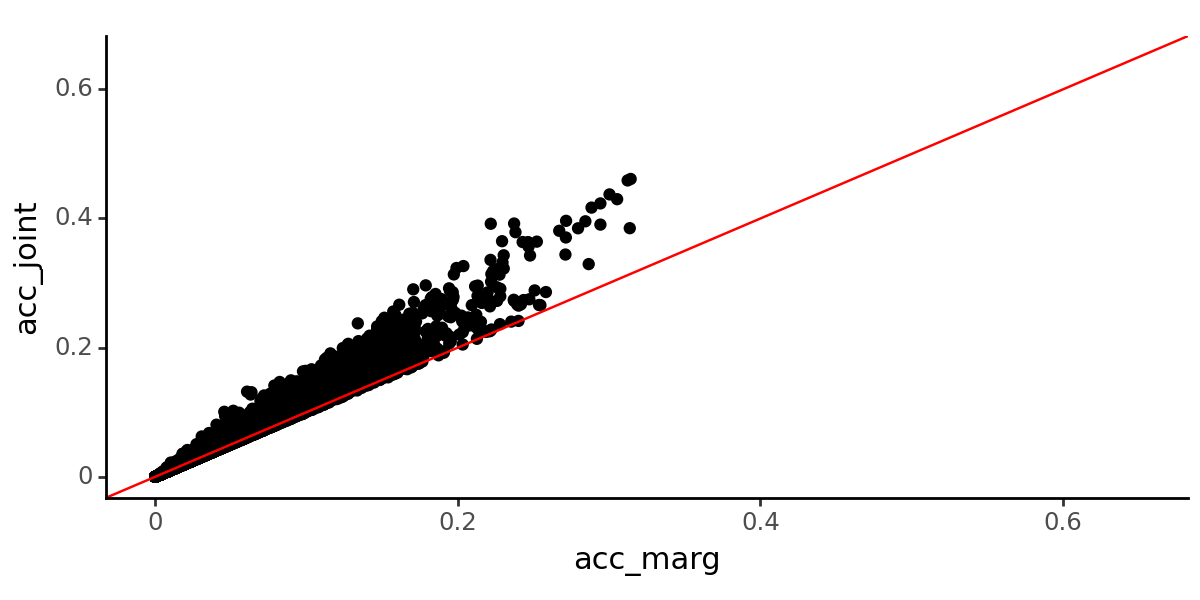

<Figure Size: (600 x 300)>

In [16]:
plotnine.options.figure_size = (6, 3)
(ggplot(data = outcome_df, mapping = aes(x = 'acc_marg', y = 'acc_joint'))+
    geom_point()+ 
    geom_abline(intercept = 0, slope = 1, color = 'red')+
     scale_x_continuous(limits = (0, .65))+
     scale_y_continuous(limits = (0, .65))+
    theme_classic())

## Simulate S/OS with stabilized binding

In [17]:
#All changes
outcome_df = generate_L_2TFs_2c(gA_list=[0.05, 0.9], gB_list=[0.001,0.5],
                                d_list=[.001,0.05], 
                                a1A_list=[1,10], a1B_list=[1,10], 
                                a2Af_list=[1,5], a2Bf_list=[1,10],
                                betanA_list = [5, 5],  betanB_list = [5, 5], #likelihood to bind to the nucleosome,
                                betamA_list = [2, 10],  betamB_list = [2, 10],
                                konA = .1, konB = .1, KA = .1,
                                trials = simulation_n)
outcome_df.to_csv('tsv/kinetics/kinetics_8state_scenarios_SvsOS.tsv.gz', sep = '\t', index = False)
outcome_df.head()

,acc_joint,acc_marg,gAvals,gBvals,a1Avals,a1Bvals,a2Avals,a2Bvals,acc_coopvals,acc_null,acc_A,acc_B,acc_AB,parset
0,0.010971,0.010512,0.657911,0.301779,5.903949,4.812893,2.533766,8.125525,0.042747,0.03652,0.038674,0.044877,0.047491,"0.1,0.1,1.0,1.0,0.6579109614165566,0.301778924..."
1,0.188278,0.176614,0.662276,0.001057,3.720993,2.320803,3.155267,4.772751,0.063954,0.025963,0.028261,0.20028,0.214241,"0.1,0.1,1.0,1.0,0.6622758194258345,0.001057073..."
2,0.074142,0.057482,0.072037,0.275282,4.917902,4.78331,2.067309,6.590204,0.254515,0.028656,0.07358,0.041214,0.102799,"0.1,0.1,1.0,1.0,0.07203729705370764,0.27528157..."
3,0.065559,0.058619,0.651926,0.146161,5.597448,9.036523,2.763239,1.268886,0.111893,0.03688,0.042484,0.089896,0.102439,"0.1,0.1,1.0,1.0,0.6519256492253891,0.146161464..."
4,0.01966,0.019003,0.515147,0.486369,7.433344,7.279559,2.739166,8.014446,0.033972,0.066061,0.069117,0.082009,0.085721,"0.1,0.1,1.0,1.0,0.515147411799364,0.4863694956..."


# Simulate 2TF,8-state pioneering over changing concentrations 

Note that in this case the non-cooperative are very strong B alone.

In [18]:
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import ListedColormap, BoundaryNorm

#Annotate concentration curve simulation points
kon_range=np.logspace(-3,3,num=100)
kon_range_df = pd.DataFrame(kon_range, columns=['kon'])
log_kon_range = np.log10(kon_range)
kon_range_df.to_csv('tsv/kinetics/conc_by_seq.tsv.gz', sep = '\t', index = False)
len(kon_range)

100

## Run non-equilibrium controls for parameter plateaus (Sox2)

We expect the plateau (i.e. pioneering potential) of Sox2 pioneering effects to be influenced by certain parameters (d, o, c, beta, and g). Show changing parameters over different Sox2 concentrations. Model this based on function below with 2TF concentration changes, but simplify it to 1TF.

In [19]:
koff=1
kon_range=np.logspace(-3,3,num=100)
increments = 10

#Set dvalues
# d_values=[0.001,0.0025,0.005,0.01,0.05] #when kopen = 0.05
d_range = [0.001,.05]
d_values = np.logspace(np.log10(d_range[0]),np.log10(d_range[1]),increments)
print(d_values)

#Set betam values
betamA_limits = [2, 10]
betamA_list=np.linspace(betamA_limits[0],betamA_limits[1],increments)

#Set affinities
affinity_range=[0.01,0.75]
affinity_limits=np.logspace(np.log10(affinity_range[0]),np.log10(affinity_range[1]),increments)
print(affinity_limits)

#Set opening values
a1_list=[2, 10]
a1_limits=np.logspace(np.log10(a1_list[0]),np.log10(a1_list[1]),increments)
print(a1_limits)

#Set closing values
a2_list=[2, 10]
a2_limits=np.logspace(np.log10(a2_list[0]),np.log10(a2_list[1]),increments)
print(a2_limits)

#For different kon values
controls_1tf_sox2_df = pd.DataFrame()

#Simulate affinity values
for r in affinity_limits:
    df = generate_input_output_2TFs_2c_Aonlychange_ns(gA_list=[r, r], gB_list=[0.08,0.08],
                                        d_list=[.05,.05],
                                        a1A_list=[6,6], a1B_list=[6,6], 
                                        a2Af_list=[3.25,3.25], a2Bf_list=[3.25,3.25],
                                        betanA_list = [2,2],  betanB_list = [2,2], #likelihood to bind to the nucleosome,
                                        betamA_list = [5,5],  betamB_list = [5,5],
                                        koff=1,konrange=kon_range,
                                        trials = 1,sameclosingeffect=True)
    df['control'] = 'affinity'
    controls_1tf_sox2_df = pd.concat([controls_1tf_sox2_df, df])

#Simulate opening values
for r in a1_limits:
    df = generate_input_output_2TFs_2c_Aonlychange_ns(gA_list=[0.08,0.08], gB_list=[0.08,0.08],
                                        d_list=[.05,.05],
                                    a1A_list=[r,r], a1B_list=[6,6], 
                                    a2Af_list=[3.25,3.25], a2Bf_list=[3.25,3.25],
                                    betanA_list = [2,2],  betanB_list = [2,2], #likelihood to bind to the nucleosome,
                                    betamA_list = [5,5],  betamB_list = [5,5],
                                    koff=1,konrange=kon_range,
                                    trials = 1,sameclosingeffect=True)
    df['control'] = 'opening'
    controls_1tf_sox2_df = pd.concat([controls_1tf_sox2_df, df])

#Simulate closing values
for r in a2_limits:
    df = generate_input_output_2TFs_2c_Aonlychange_ns(gA_list=[0.08,0.08], gB_list=[0.08,0.08],
                                        d_list=[.05,.05],
                                    a1A_list=[6,6], a1B_list=[6,6], 
                                    a2Af_list=[r,r], a2Bf_list=[3.25,3.25],
                                    betanA_list = [2,2],  betanB_list = [2,2], #likelihood to bind to the nucleosome,
                                    betamA_list = [5,5],  betamB_list = [5,5],
                                    koff=1,konrange=kon_range,
                                    trials = 1,sameclosingeffect=True)
    df['control'] = 'closing'
    controls_1tf_sox2_df = pd.concat([controls_1tf_sox2_df, df])

for r in d_values:
    df = generate_input_output_2TFs_2c_Aonlychange_ns(gA_list=[0.08,0.08], gB_list=[0.08,0.08],
                                    d_list=[r,r],
                                    a1A_list=[6,6], a1B_list=[6,6], 
                                    a2Af_list=[3.25,3.25], a2Bf_list=[3.25,3.25],
                                    betanA_list = [2,2],  betanB_list = [2,2], #likelihood to bind to the nucleosome,
                                    betamA_list = [5,5],  betamB_list = [5,5],
                                    koff=1,konrange=kon_range,
                                    trials = 1,sameclosingeffect=True)
    df['control'] = 'd'
    controls_1tf_sox2_df = pd.concat([controls_1tf_sox2_df, df])

for r in betamA_list:
    df = generate_input_output_2TFs_2c_Aonlychange_ns(gA_list=[0.08,0.08], gB_list=[0.08,0.08],
                                        d_list=[.05,.05],
                                    a1A_list=[6,6], a1B_list=[6,6], 
                                    a2Af_list=[3.25,3.25], a2Bf_list=[3.25,3.25],
                                    betanA_list = [2,2],  betanB_list = [2,2], #likelihood to bind to the nucleosome,
                                    betamA_list = [r,r],  betamB_list = [5,5],
                                    koff=1,konrange=kon_range,
                                    trials = 1,sameclosingeffect=True)
    df['control'] = 'betam'
    controls_1tf_sox2_df = pd.concat([controls_1tf_sox2_df, df])

controls_1tf_sox2_df.to_csv('tsv/kinetics/kinetics_8state_parameter_controls_for_Aonly_sox2.tsv', sep = '\t', index = False)
controls_1tf_sox2_df.head()

[0.001      0.00154445 0.00238533 0.00368403 0.00568981 0.00878764
 0.01357209 0.02096144 0.03237394 0.05      ]
[0.01       0.01615623 0.02610239 0.04217163 0.06813348 0.11007804
 0.17784467 0.28733001 0.46421709 0.75      ]
[ 2.          2.39162635  2.8599383   3.41995189  4.08962353  4.8904257
  5.84803548  6.99315787  8.36251031 10.        ]
[ 2.          2.39162635  2.8599383   3.41995189  4.08962353  4.8904257
  5.84803548  6.99315787  8.36251031 10.        ]


,acc_coopvals,acc_null,acc_A,acc_B,acc_AB,acc_Aonly,acc_Bonly,bind_Aonly,bind_Bonly,bindA_ABonly,bindB_ABonly,parset,control
0,"0.10659014693466261,0.11860369095681055,0.1314...","0.06227389181023378,0.06230189325418165,0.0623...","0.07514265011057475,0.07704879384668939,0.0792...","0.14259970116524598,0.14265754164961955,0.1427...","0.16595081758173788,0.16938009922802072,0.1732...","0.058078957751242,0.059609762077284065,0.06135...","0.1422133009302467,0.1422133009302467,0.142213...","0.027078820867520698,0.031024966649626517,0.03...","0.25241065094848425,0.25241065094848425,0.2524...","0.037602587926441104,0.04304026426697209,0.049...","0.26095268352038276,0.2621864225006537,0.26359...","1000.0,0.1,1,1,0.01,0.08,2.0,2.0,5.0,5.0,1,1,0...",affinity
0,"0.0704931059407857,0.07938401892337803,0.08915...","0.06227389181023378,0.06230189325418165,0.0623...","0.06969513071094277,0.07082072155135172,0.0721...","0.14259970116524598,0.14265754164961955,0.1427...","0.15642973641370897,0.15851917832540416,0.1609...","0.053681661965276545,0.05457985632316649,0.055...","0.1422133009302467,0.1422133009302467,0.142213...","0.016314067971825708,0.01872090636018109,0.021...","0.25241065094848425,0.25241065094848425,0.2524...","0.022382892343583944,0.02567565521725746,0.029...","0.25753429213371754,0.2582871613001076,0.25914...","1000.0,0.1,1,1,0.0161562342119486,0.08,2.0,2.0...",affinity
0,"0.044825528962256625,0.05088292590729636,0.057...","0.06227389181023378,0.06230189325418165,0.0623...","0.06652990761717696,0.06719181330364737,0.0679...","0.14259970116524598,0.14265754164961955,0.1427...","0.15073340250710207,0.15199725496711233,0.1534...","0.05114153338185039,0.05166675855049513,0.0522...","0.1422133009302467,0.1422133009302467,0.142213...","0.009831099497817585,0.011291518738428144,0.01...","0.25241065094848425,0.25241065094848425,0.2524...","0.013338095975007788,0.015318220523702788,0.01...","0.25548563413467923,0.25594168247353616,0.2564...","1000.0,0.1,1,1,0.026102390391133826,0.08,2.0,2...",affinity
0,"0.027612575598178694,0.03150154076758085,0.035...","0.06227389181023378,0.06230189325418165,0.0623...","0.0647048891043889,0.06509620319062624,0.06554...","0.14259970116524598,0.14265754164961955,0.1427...","0.14734766868494661,0.14811289695131588,0.1489...","0.04968551723874845,0.049994565402507234,0.050...","0.1422133009302467,0.1422133009302467,0.142213...","0.0059488791055766245,0.006835885334024631,0.0...","0.25241065094848425,0.25241065094848425,0.2524...","0.00799845948676149,0.009191303600751322,0.010...","0.2542659091290147,0.25454237636606686,0.25485...","1000.0,0.1,1,1,0.042171633265087445,0.08,2.0,2...",affinity
0,"0.0164549736714885,0.01883033628638961,0.02153...","0.06227389181023378,0.06230189325418165,0.0623...","0.06364733742045961,0.063880905604054,0.064149...","0.14259970116524598,0.14265754164961955,0.1427...","0.1453286275814948,0.1457940291858128,0.146328...","0.048846434105442156,0.049030215516356015,0.04...","0.1422133009302467,0.1422133009302467,0.142213...","0.003619234256150727,0.0041599462171471036,0.0...","0.25241065094848425,0.25241065094848425,0.2524...","0.004833895063197887,0.005556369768468459,0.00...","0.25353743528540584,0.25370574848348354,0.2538...","1000.0,0.1,1,1,0.06813347841311554,0.08,2.0,2....",affinity


## Run equilibrium controls for parameter plateaus (Sox2)

We expect the plateau (i.e. pioneering potential) of Sox2 pioneering effects to be influenced by certain parameters (d, o, c, beta, and g). Show changing parameters over different Sox2 concentrations. Model this based on a modified equilibrium function below.

In [20]:
def generate_input_output_equilibrium(gA_list, #affinities of each TF

    #These values will hang empty in the `model_1TF_equilibrium` function              
       a1A_list,  #opening effects of each TF
       a2Af_list, #closing effects of each TF            
       betanA_list = [2,4],  #increase in off-rate due to nucleosome, non-specific DNA
       betamA_list = [5, 10],   #increase in off-rate due to nucleosome, DNA with motif
       kopen0=0.001, 
       konrange=None, koff=1, 
       d_list=[0.05,0.5],
       h1=1, h0=1, #binding interactions BETWEEN two TFs
       trials = 10000,
       sameclosingeffect=True): #extra parameters
    """
    A given TF increases the opening rate by an amount i_x, and when both are bound, the amounts multiplies, 8-state model
    Consider only parameter sets where both A and B individually increase accessibility
    Assume that the effect of the TF does not change when it is bound to a motif with respect to when it is bound non-specifically (sameclosingeffect=True), or only a1 does not change.
    """      
    #yvals=[]; xvals=[]; gAvals=[]; gBvals=[]; a1Avals=[]; a1Bvals=[]; a2Avals=[]; a2Bvals=[]; 
    parsets=[]; A0vals=[]; AAvals=[]; b0vals=[]; bAvals=[];

    negativepsets=0
    
    for i in range(trials):
        np.random.seed(i)
        # kopen0=0.05 #10**np.random.uniform(-4,-2) #assume opening happens in the minutes to hours range
        d=np.random.uniform(d_list[0],d_list[1]) #if dmax is too large, then less cooperativity because it is already open
        kclose0=kopen0/d #np.random.uniform(0.001,0.01)
    
        konA=konB=0.1 #redundant, see below it gets redefined
        # KA=1 #np.random.uniform(1,5)
        koff1nA=koff
        
        gA=np.random.uniform(gA_list[0],gA_list[1]) 
        
        a1A=np.random.uniform(a1A_list[0],a1A_list[1]) 
        a1Afactorincrease=1 #np.random.uniform(1,3) #small values here generate more cooperativity, 
        a1nA=a1A
        a1mA=a1nA*a1Afactorincrease
    
        betanA=np.random.uniform(betanA_list[0],betanA_list[1]) #np.random.normal(5,0.1)
        betamA=np.random.uniform(betamA_list[0],betamA_list[1])
    
        #assume some effect on the closing
        a2mAf=np.random.uniform(a2Af_list[0], a2Af_list[1]) #a2nAf*np.random.uniform(1,2) #min(np.random.normal(0.8,0.15),1) 
        if sameclosingeffect:
            a2nAf = a2mAf
        else:
            a2nAf=1
        

        a2nA=1/a2nAf; a2mA=1/a2mAf; 

        A0vals_=[]; AAvals_=[];
        b0vals_=[]; bAvals_=[];
        AAalonevals_=[];
        cooperativity_=[]
        parset_list = []
        
        for kon in konrange:

            #a1/a2 values will hang empty in the `model_1TF_equilibrium` function              
            parsetA=np.array([kon,koff1nA,gA,betanA,betamA, kopen0,kclose0, a1nA, a2nA, a1mA, a2mA])
            A0_Aalone, A_Aalone, b0_Aalone, bA_Aalone=model_1TF_equilibrium(parsetA)

            A0vals_.append(A0_Aalone);AAvals_.append(A_Aalone);         
            b0vals_.append(b0_Aalone);bAvals_.append(bA_Aalone);
            
            parset_list.append(parsetA)

        A0vals.append(",".join(list(map(str,A0vals_))))
        AAvals.append(",".join(list(map(str,AAvals_))))
    
        b0vals.append(",".join(list(map(str,b0vals_))))
        bAvals.append(",".join(list(map(str,bAvals_))))

        parsets.append(",".join(list(map(str,parsetA))));
                
        
    outcome_df = pd.DataFrame([A0vals, AAvals, b0vals, bAvals,parsets]).transpose()
    outcome_df.columns = ['acc_null','acc_A','bind_null','bind_A','parset']
    return outcome_df     

Next, apply 1TF equilibrium model using the above ranges for the non-equilibrium model.

In [21]:


#For different kon values
controls_1tf_sox2_df = pd.DataFrame()

#Simulate affinity values
for r in affinity_limits:
    df = generate_input_output_equilibrium(gA_list=[r, r], 
                                        d_list=[.05,.05],
                                        a1A_list=[6,6], 
                                        a2Af_list=[3.25,3.25], 
                                        betanA_list = [2,2],  #likelihood to bind to the nucleosome,
                                        betamA_list = [5,5],  
                                        koff=1, konrange=kon_range,
                                        trials = 1,sameclosingeffect=True)
    df['control'] = 'affinity'
    controls_1tf_sox2_df = pd.concat([controls_1tf_sox2_df, df])

for r in d_values:
    df = generate_input_output_equilibrium(gA_list=[0.08,0.08], 
                                    d_list=[r,r],
                                    a1A_list=[6,6],
                                    a2Af_list=[3.25,3.25], 
                                    betanA_list = [2,2],  #likelihood to bind to the nucleosome,
                                    betamA_list = [5,5],  
                                    koff=1, konrange=kon_range,
                                    trials = 1,sameclosingeffect=True)
    df['control'] = 'd'
    controls_1tf_sox2_df = pd.concat([controls_1tf_sox2_df, df])

for r in betamA_list:
    df = generate_input_output_equilibrium(gA_list=[0.08,0.08], 
                                        d_list=[.05,.05],
                                    a1A_list=[6,6],                                     
                                    a2Af_list=[3.25,3.25], 
                                    betanA_list = [2,2],  #likelihood to bind to the nucleosome,
                                    betamA_list = [r,r],  
                                    koff=1,konrange=kon_range,
                                    trials = 1,sameclosingeffect=True)
    df['control'] = 'betam'
    controls_1tf_sox2_df = pd.concat([controls_1tf_sox2_df, df])

controls_1tf_sox2_df.to_csv('tsv/kinetics/kinetics_4state_parameter_controls_for_equilibrium_sox2.tsv', sep = '\t', index = False)
controls_1tf_sox2_df.head()

,acc_null,acc_A,bind_null,bind_A,parset,control
0,"0.047641711484460524,0.047645103513986646,0.04...","0.051162790697674425,0.051679350113545006,0.05...","0.0005235352910380277,0.0006018911730914791,0....","0.023255813953488375,0.026645735120139062,0.03...","1000.0,1.0,0.01,2.0,5.0,0.001,0.02,6.0,0.30769...",affinity
0,"0.047641711484460524,0.047645103513986646,0.04...","0.04983207982929303,0.05015797490885378,0.0505...","0.0005235352910380277,0.0006018911730914791,0....","0.014523023879735527,0.016661710339352948,0.01...","1000.0,1.0,0.0161562342119486,2.0,5.0,0.001,0....",affinity
0,"0.047641711484460524,0.047645103513986646,0.04...","0.048996439807218295,0.049200573053126806,0.04...","0.0005235352910380277,0.0006018911730914791,0....","0.009039136234870043,0.010378760661144635,0.01...","1000.0,1.0,0.026102390391133826,2.0,5.0,0.001,...",affinity
0,"0.047641711484460524,0.047645103513986646,0.04...","0.048474539517223754,0.04860182912953955,0.048...","0.0005235352910380277,0.0006018911730914791,0....","0.005614165581780841,0.006449503662603338,0.00...","1000.0,1.0,0.042171633265087445,2.0,5.0,0.001,...",affinity
0,"0.047641711484460524,0.047645103513986646,0.04...","0.048149694746220766,0.04822884485053296,0.048...","0.0005235352910380277,0.0006018911730914791,0....","0.0034823717720737545,0.004001794331622586,0.0...","1000.0,1.0,0.06813347841311554,2.0,5.0,0.001,0...",affinity


## Model cooperativities over different ranges (Sox2 changes, TFB doesn't)

Here, Sox2 concentration and affinity will change, while TF B (a generic pioneer of comparable strength) concentration and affinity will not change. Same analysis as above, but makes a little more sense in terms of biological simulations. Don't expect much change, just a nice alignment of results to show many different parameter regimes will trend in the same direction.

In [22]:
gA_range=[0.05,0.9]
gA_limits=np.logspace(np.log10(gA_range[0]),np.log10(gA_range[1]),5)
gB_list=[0.1,0.1]

print(gA_limits)
a1_list=[2,10]
a1_limits=np.linspace(a1_list[0],a1_list[1],5)
print(a1_limits)
a2_list=[1,10]
a2_limits=np.linspace(a2_list[0],a2_list[1],5)
print(a2_limits)

[0.05       0.10298836 0.21213203 0.43694259 0.9       ]
[ 2.  4.  6.  8. 10.]
[ 1.    3.25  5.5   7.75 10.  ]


## Model Sox2 vs static TF B

At varieties of different pioneering effects (a1 and a2) and opening effects (d), create multiple scenarios where a changing Sox2 cooperates with an UNCHANGING other pioneer of a designated strength.

In [23]:
trial_n=5
d_values=[0.001,0.005,0.007,0.01,0.05]
betam=5
koff=1

for same in [True,False]:
    for d in d_values:
        d_list=[d,d]
        for tier2 in range(1,5): #from weak to strong
            a1_list=[a1_limits[tier2-1],a1_limits[tier2]]
            a2f_list=[a2_limits[tier2-1],a2_limits[tier2]]
            for t,tier1 in enumerate([1,2,3,4]): 
                gA_list=[gA_limits[-(tier1+1)],gA_limits[-(tier1)]] #from low to high affinity 
                vars_for_name=[same]+gA_list+a1_list+a2f_list+d_list+[betam]
                vars_for_name=tuple(vars_for_name)
                fname='tsv/kinetics/os_sameclosing=%s_gA=%2.2f-%2.2f_a1=%2.2f-%2.2f_a2f=%2.2f-%2.2f_d=%g-%g_betam=%g.tsv.gz'%vars_for_name     
                outcome_df = generate_input_output_2TFs_2c_Aonlychange_ns(gA_list=gA_list, gB_list=gB_list,
                                                    d_list=d_list,
                                                    a1A_list=a1_list, a1B_list=a1_list, 
                                                    a2Af_list=a2f_list, a2Bf_list=a2f_list,
                                                    betanA_list = [5,5],  betanB_list = [5,5], #likelihood to bind to the nucleosome,
                                                    betamA_list = [betam,betam],  betamB_list = [betam,betam],
                                                    koff=1,konrange=kon_range,
                                                    trials = trial_n,sameclosingeffect=same)
                outcome_df.to_csv(fname, sep = '\t', index = False)

## Model Sox2 vs changing TF B

Generate plots where we change gA/gB in a two TF conformation (high/high, high/low, low/high, low/low) across concentrations where (A change, B change, both change) to show that motif affinity and concentration play in higher order fashions due to cooperativity. 

In [24]:
def generate_input_output_2TFs_2c_ABchange_ns(gA_list, gB_list, #affinities of each TF
                       a1A_list, a1B_list, #opening effects of each TF
                       a2Af_list, a2Bf_list, #closing effects of each TF
                       betanA_list = [2,4],  betanB_list = [2,4], #increase in off-rate due to nucleosome, non-specific DNA
                       betamA_list = [5, 10],  betamB_list = [5, 10], #increase in off-rate due to nucleosome, DNA with motif
                       kopen0=0.001, 
                       konArange=None, 
                       konBrange=None, 
                       koff=1, 
                       d_list=[.001,0.05],
                       h1=1, h0=1, #binding interactions BETWEEN two TFs
                       trials = 10000,
                       sameclosingeffect=True): #extra parameters
    """
    A given TF increases the opening rate by an amount i_x, and when both are bound, the amounts multiplies, 8-state model
    Consider only parameter sets where both A and B individually increase accessibility
    Assume that the effect of the TF does not change when it is bound to a motif with respect to when it is bound non-specifically (sameclosingeffect=True), or only a1 does not change.
    """      
    #yvals=[]; xvals=[]; gAvals=[]; gBvals=[]; a1Avals=[]; a1Bvals=[]; a2Avals=[]; a2Bvals=[]; 
    parsets=[]; A0vals=[]; AAvals=[]; ABvals=[]; AABvals=[]
    AAalonevals=[];ABalonevals=[];
    bAalonevals=[];bBalonevals=[];bA_ABvals=[];bB_ABvals=[];
    cooperativities=[];
    # bA_0vals = []; bA_Avals = []; bA_Bvals = []; bA_ABvals.append(b_AB);
    # bB_0vals.append(bB_0);bB_Avals.append(bB_A);bB_Bvals.append(bB_B);bB_ABvals.append(bB_AB);    
    
    negativepsets=0
    
    for i in range(trials):
        np.random.seed(i)
        # kopen0=0.001 #10**np.random.uniform(-4,-2) #assume opening happens in the minutes to hours range
        d=np.random.uniform(d_list[0],d_list[1]) #if dmax is too large, then less cooperativity because it is already open
        kclose0=kopen0/d #np.random.uniform(0.001,0.01)
    
        # KA=1 #np.random.uniform(1,5)
        koff1nA=koff
        koff1nB=koff
        
        gA=np.random.uniform(gA_list[0],gA_list[1]) 
        gB=np.random.uniform(gB_list[0],gB_list[1])
        
        a1A=np.random.uniform(a1A_list[0],a1A_list[1]) 
        a1Afactorincrease=1 #np.random.uniform(1,3) #small values here generate more cooperativity, 
        a1nA=a1A
        a1mA=a1nA*a1Afactorincrease
    
        a1B=np.random.uniform(a1B_list[0],a1B_list[1]) 
        a1Bfactorincrease=1 #np.random.uniform(1,2)
        a1nB=a1B
        a1mB=a1nB*a1Bfactorincrease
    
        betanA=np.random.uniform(betanA_list[0],betanA_list[1]) #np.random.normal(5,0.1)
        betamA=np.random.uniform(betamA_list[0],betamA_list[1])
    
        betanB=np.random.uniform(betanB_list[0],betanB_list[1]) #np.random.normal(5,0.1)
        betamB=np.random.uniform(betamB_list[0],betamB_list[1])

    
        #assume some effect on the closing
        a2mAf=np.random.uniform(a2Af_list[0], a2Af_list[1]) #a2nAf*np.random.uniform(1,2) #min(np.random.normal(0.8,0.15),1) 
        if sameclosingeffect:
            a2nAf = a2mAf
        else:
            a2nAf=1
        
        a2mBf=np.random.uniform(a2Bf_list[0], a2Bf_list[1]) #a2nBf*np.random.uniform(1,2) #np.random.uniform(1,2) #min(np.random.normal(0.8,0.15),1) 
        if sameclosingeffect:
            a2nBf = a2mBf
        else:
            a2nBf=1
        
        a2nA=1/a2nAf; a2mA=1/a2mAf; a2nB=1/a2nBf; a2mB=1/a2mBf
        #assert a2nA==a2mA
        #assert a2nB==a2mB
            
        a1nAB=a1nA*a1nB; a1mAmB=a1mA*a1mB; a1mAnB=a1mA*a1nB; a1nAmB=a1nA*a1mB
        a2nAB=1/(a2nAf*a2nBf); a2mAnB=1/(a2mAf*a2nBf); a2nAmB=1/(a2nAf*a2mBf); a2mAmB=1/(a2mAf*a2mBf)
    
        parslist=[koff1nA,koff1nB,gA,gB,betanA, betanB, betamA, betamB,h0,h1, kopen0,kclose0, a1nA, a1nB, a1nAB, a1mA, a1mB, a1mAnB, a1nAmB, a1mAmB, a2nA, a2nB, a2nAB, a2mA, a2mB, a2mAnB, a2nAmB, a2mAmB]

        A0vals_=[]; AAvals_=[]; ABvals_=[]; AABvals_=[]
        AAalonevals_=[];ABalonevals_=[];bAalonevals_=[];bBalonevals_=[];bA_ABvals_=[];bB_ABvals_=[];
        konA_ = []; konB_ = []
        cooperativity_=[]
        parset_list = []

        outcome_df = pd.DataFrame()
        for konA in konArange:
            for konB in konBrange:
            
                parset=[konA,konB]+parslist
                    
                parsetar=np.array(parset)
                if not np.all(parsetar>=0):
                    negativepsets+=1
                    print("negativepsets")
    
                else:
                    parsetA=np.array([konA,koff1nA,gA,betanA,betamA, kopen0,kclose0, a1nA,a2nA, a1mA, a2mA])
                    parsetB=np.array([konB,koff1nB,gB,betanB,betamB,kopen0,kclose0,a1nB,a2nB,a1mB,a2mB])
                    
                    A0_Aalone, A_Aalone, b0_Aalone, bA_Aalone=model_1TF_reference_nakednomotif(parsetA,idx_openconc=2,Lfunc=L_1TF_2c, 
                                                                                               returnb=True, idxs_bound=[1,3])
                    A0_Balone, A_Balone, b0_Balone, bA_Balone=model_1TF_reference_nakednomotif(parsetB,idx_openconc=2,Lfunc=L_1TF_2c, 
                                                                                               returnb=True, idxs_bound=[1,3])
                    # A_0, A_A, A_B, A_AB =model_2TFs_reference_nakednomotif(parsetar, idx_openconc=4, Lfunc=L_2TFs_2c)
                    A_0, A_A, A_B, A_AB, b_0, b_A, b_B, b_AB,bB_0, bB_A, bB_B, bB_AB =model_2TFs_reference_nakednomotif(parset, idx_openconc=4, Lfunc=L_2TFs_2c, 
                                                                                                                        returnb=True, idxs_bound=[1,3,5,7])
                    
                    A0vals_.append(A_0);AAvals_.append(A_A);ABvals_.append(A_B);AABvals_.append(A_AB);
                    AAalonevals_.append(A_Aalone);
                    ABalonevals_.append(A_Balone)
                    
                    bAalonevals_.append(bA_Aalone);
                    bBalonevals_.append(bA_Balone)
                    bA_ABvals_.append(b_AB)
                    bB_ABvals_.append(bB_AB)
    
                    konA_.append(konA)
                    konB_.append(konB)
    
                    parset_list.append(parset)
                    if A_AB-A_0<1e-10:
                        coop = -1000
                        cooperativity_.append(-1000)
                    else:
                        coop = np.log((A_AB-A_0)/(1e-10+A_A-A_0+A_B-A_0))
                        cooperativity_.append(np.log((A_AB-A_0)/(1e-10+A_A-A_0+A_B-A_0)))

                o_df = pd.DataFrame([coop,A_0, A_A, A_B, A_AB,A_Aalone,A_Balone, bA_Aalone, bA_Balone, b_AB, bB_AB, konA, konB]).transpose()
                o_df.columns = ['acc_coopvals','acc_null','acc_A','acc_B','acc_AB', 'acc_Aonly','acc_Bonly','bind_Aonly','bind_Bonly','bindA_ABonly', 'bindB_ABonly', 'konA', 'konB']
            
                outcome_df = pd.concat([outcome_df, o_df])
        return(outcome_df)
        

In [25]:
trial_n=5
a1_list=[4,6] #range allowed
a2_list=[3.25,5.50] #range allowed
d_list = [0.01, 0.01]
betam=5
koff=1


scenarios_dict = {
    'gA_high_gB_high' : {'gA' : 0.05, 'gB' : 0.05},
    'gA_high_gB_low' : {'gA' : 0.05, 'gB' : 0.4},
    'gA_low_gB_high' : {'gA' : 0.4, 'gB' : 0.05},
    'gA_low_gB_low' : {'gA' : 0.4, 'gB' : 0.4},
}

conc_dict = {
    'A_change_B_static' : {'konA_range' : kon_range, 'konB_range' : [.1]},
    'A_change_B_change' : {'konA_range' : kon_range, 'konB_range' : kon_range}
}

outcomes_df = pd.DataFrame()
for k,v in scenarios_dict.items():
    for k1,v1 in conc_dict.items():
        outcome_df = generate_input_output_2TFs_2c_ABchange_ns(gA_list=[v['gA'], v['gA']], gB_list=[v['gB'], v['gB']],
                                            d_list=d_list,
                                            a1A_list=a1_list, a1B_list=a1_list, 
                                            a2Af_list=a2f_list, a2Bf_list=a2f_list,
                                            betanA_list = [5,5],  betanB_list = [5,5], #likelihood to bind to the nucleosome,
                                            betamA_list = [betam,betam],  betamB_list = [betam,betam],
                                            koff=1,
                                                               konArange = v1['konA_range'],
                                                               konBrange = v1['konB_range'],
                                            trials = trial_n,sameclosingeffect=True)
        outcome_df['affinity_scenario'] = k
        outcome_df['conc_scenario'] = k1
        outcomes_df = pd.concat([outcomes_df, outcome_df])

outcomes_df.to_csv('tsv/kinetics/S_vs_TFB_changing_variables.tsv', sep = '\t', index = False)

In [26]:
outcomes_df.head()

,acc_coopvals,acc_null,acc_A,acc_B,acc_AB,acc_Aonly,acc_Bonly,bind_Aonly,bind_Bonly,bindA_ABonly,bindB_ABonly,konA,konB,affinity_scenario,conc_scenario
0,0.031605,0.011663,0.012301,0.060738,0.062972,0.010481,0.060647,0.004369,0.3119,0.005436,0.312828,0.001000,0.1,gA_high_gB_high,A_change_B_static
0,0.036173,0.011666,0.012400,0.060751,0.063320,0.010568,0.060647,0.005020,0.3119,0.006247,0.312967,0.001150,0.1,gA_high_gB_high,A_change_B_static
0,0.041374,0.011670,0.012513,0.060767,0.063720,0.010668,0.060647,0.005768,0.3119,0.007179,0.313126,0.001322,0.1,gA_high_gB_high,A_change_B_static
0,0.047287,0.011674,0.012643,0.060785,0.064179,0.010783,0.060647,0.006627,0.3119,0.008248,0.313310,0.001520,0.1,gA_high_gB_high,A_change_B_static
0,0.054001,0.011678,0.012793,0.060805,0.064708,0.010914,0.060647,0.007613,0.3119,0.009477,0.313521,0.001748,0.1,gA_high_gB_high,A_change_B_static


These .tsv files will be processed in `19*.Rmd` for clearer visualizations.